# GNN Notebook test

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from math import sqrt

from rdkit import Chem
from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from rdkit.Chem.Draw import IPythonConsole
from tqdm import tqdm

import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import AttentiveFP

#-------------------

import os 
import random
from collections import Counter

import torch

from torch_geometric.data import InMemoryDataset, download_url, extract_gz
from sklearn.metrics import r2_score


# print(plt.style.available)
plt.style.use('ggplot')

c:\Users\elonv\miniconda3\envs\gnn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def set_seed(seed=420):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

### Init Data

In [ ]:
import pandas as pd

path = "C:\\Users\\elonv\\Documents\\Thesis\\Data\\toxicity_fish.csv"

# Init data frame
df = pd.read_csv(path)[0:200] # Add more later

selected_columns = ["SMILES", "conc"] # Convert conc to log10 later
df = df[selected_columns]

# print(data_frame.info())
print(df.head())
print(df.describe())
print(f"Number of unique SMILES: {df['SMILES'].nunique()}")
# smiles = data_frame["SMILES"].tolist()


       SMILES  conc
0  O=[O+][O-]  0.18
1  O=[O+][O-]  0.18
2  O=[O+][O-]  0.26
3  O=[O+][O-]  0.26
4  O=[O+][O-]  0.17
              conc
count   200.000000
mean     60.373048
std     200.805911
min       0.001200
25%       0.177500
50%       7.420000
75%      54.025000
max    1850.000000
Number of unique SMILES: 29


In [ ]:
# Add a molecule column to the DataFrame
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='SMILES', molCol='Molecule')

# Add molecular weight column
df['MolecularWeight'] = df['Molecule'].apply(Descriptors.MolWt)

df.head()

,SMILES,conc,Molecule,MolecularWeight
0,O=[O+][O-],0.18,<rdkit.Chem.rdchem.Mol object at 0x0000016BC41...,47.997
1,O=[O+][O-],0.18,<rdkit.Chem.rdchem.Mol object at 0x0000016BC41...,47.997
2,O=[O+][O-],0.26,<rdkit.Chem.rdchem.Mol object at 0x0000016BC41...,47.997
3,O=[O+][O-],0.26,<rdkit.Chem.rdchem.Mol object at 0x0000016BC41...,47.997
4,O=[O+][O-],0.17,<rdkit.Chem.rdchem.Mol object at 0x0000016BC41...,47.997


### Data Analysis

C:\Users\elonv\AppData\Local\Temp\ipykernel_20636\1882244044.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='SMILES', y='Count', palette='viridis')
C:\Users\elonv\AppData\Local\Temp\ipykernel_20636\1882244044.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


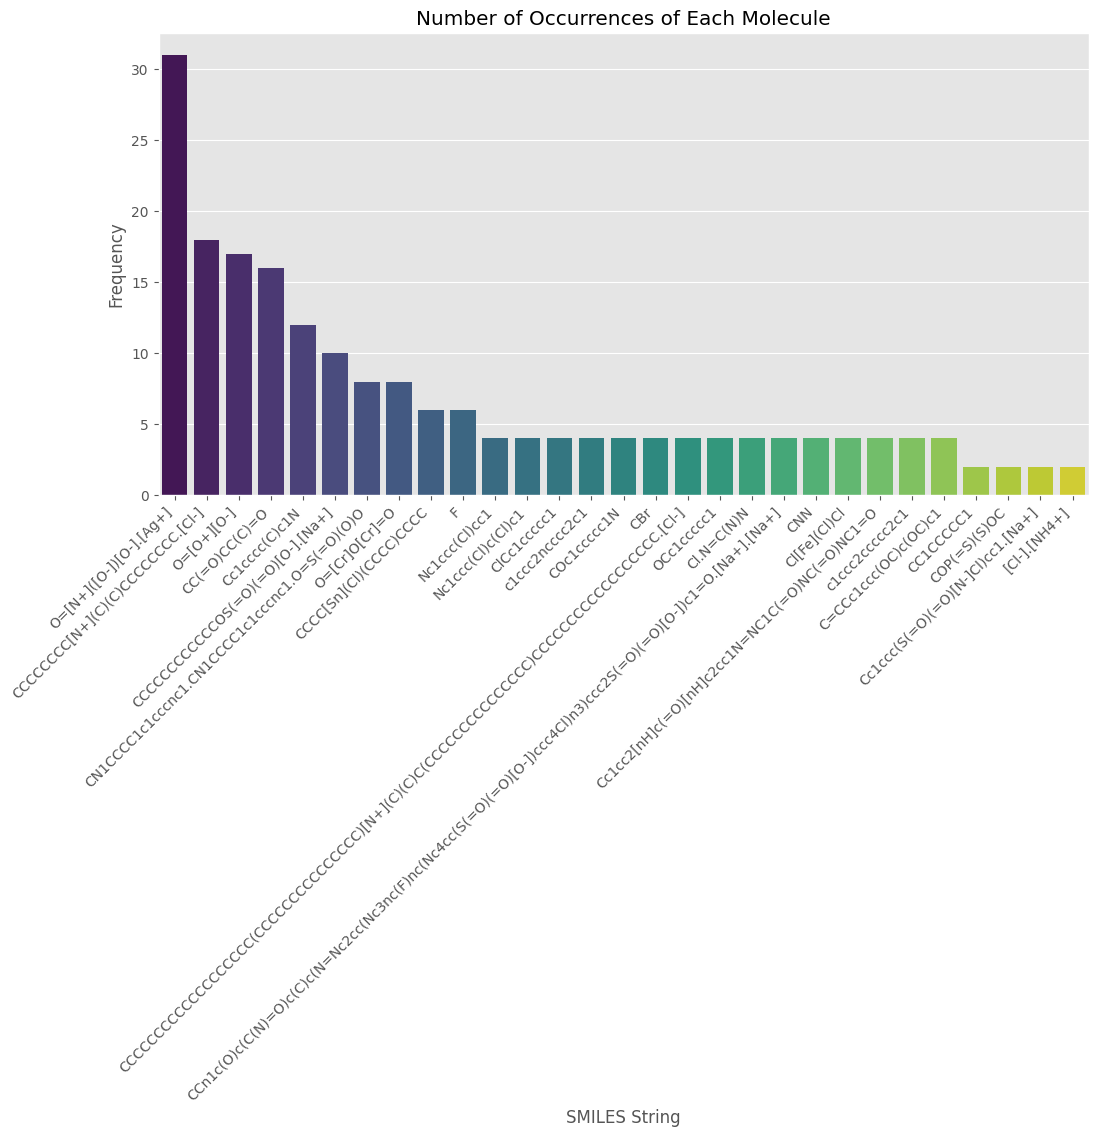

In [ ]:

counts = Counter(df['SMILES'])
# print(counts)
plot_df = pd.DataFrame(counts.items(), columns=['SMILES', 'Count'])

plot_df = plot_df.sort_values('Count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='SMILES', y='Count', palette='viridis')

plt.title('Number of Occurrences of Each Molecule')
plt.xlabel('SMILES String')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Look at one molecule

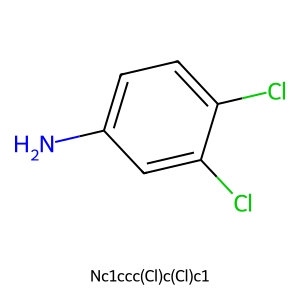

In [ ]:
# Draw molecular structure
mol_id = 16
img = Draw.MolToImage(df['Molecule'][mol_id], legend=str(df['SMILES'][mol_id]))
display(img)

### Pytorch Geometric

In [ ]:
from torch_geometric.utils import from_smiles

# Convert SMILES to PyG graph data objects
smiles = df['SMILES'].tolist()
smiles_pyg = [from_smiles(s, with_hydrogen=False) for s in smiles]
print(type(smiles_pyg[0]))

print(smiles[mol_id])
print(smiles_pyg)



<class 'torch_geometric.data.data.Data'>
['O=[O+][O-]', 'O=[O+][O-]', 'O=[O+][O-]', 'O=[O+][O-]', 'O=[O+][O-]', 'O=[O+][O-]', 'O=[O+][O-]', 'O=[O+][O-]', 'ClCc1ccccc1', 'ClCc1ccccc1', 'ClCc1ccccc1', 'ClCc1ccccc1', 'Nc1ccc(Cl)cc1', 'Nc1ccc(Cl)cc1', 'Nc1ccc(Cl)cc1', 'Nc1ccc(Cl)cc1', 'Nc1ccc(Cl)c(Cl)c1', 'Nc1ccc(Cl)c(Cl)c1', 'Nc1ccc(Cl)c(Cl)c1', 'Nc1ccc(Cl)c(Cl)c1', 'CCCCCCCCCCCCOS(=O)(=O)[O-].[Na+]', 'CCCCCCCCCCCCOS(=O)(=O)[O-].[Na+]', 'O=[Cr]O[Cr]=O', 'O=[Cr]O[Cr]=O', 'O=[Cr]O[Cr]=O', 'O=[Cr]O[Cr]=O', 'O=[Cr]O[Cr]=O', 'O=[Cr]O[Cr]=O', 'O=[Cr]O[Cr]=O', 'O=[Cr]O[Cr]=O', 'O=[N+]([O-])[O-].[Ag+]', 'O=[N+]([O-])[O-].[Ag+]', 'O=[N+]([O-])[O-].[Ag+]', 'O=[N+]([O-])[O-].[Ag+]', 'COP(=S)(S)OC', 'COP(=S)(S)OC', 'Cl.N=C(N)N', 'Cl.N=C(N)N', 'Cl.N=C(N)N', 'Cl.N=C(N)N', 'CC1CCCCC1', 'CC1CCCCC1', 'OCc1ccccc1', 'OCc1ccccc1', 'OCc1ccccc1', 'OCc1ccccc1', 'CBr', 'CBr', 'CBr', 'CBr', 'O=[N+]([O-])[O-].[Ag+]', 'O=[N+]([O-])[O-].[Ag+]', 'O=[N+]([O-])[O-].[Ag+]', 'O=[N+]([O-])[O-].[Ag+]', 'O=[N+]([O-])[O-].[A

### Netowrkx

<class 'networkx.classes.digraph.DiGraph'>


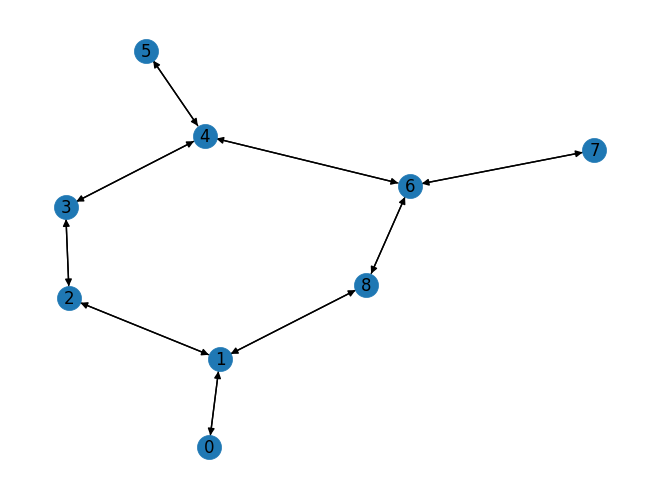

In [58]:
from torch_geometric.utils import to_networkx

# Convert to networkx graph
smiles_nx = [to_networkx(graph) for graph in smiles_pyg]
print(type(smiles_nx[0]))

nx.draw(smiles_nx[mol_id], with_labels=True)

### DeepChem

In [60]:
import deepchem as dc

# Convert to deepchem
featurizer = dc.feat.MolGraphConvFeaturizer(use_edges=True)
smiles_dc = featurizer.featurize(df['SMILES'].tolist())

print(type(smiles_dc[0]))

Failed to featurize datapoint 84, F. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 85, F. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 86, F. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 87, F. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 88, F. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 89, F. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 198, [Cl-]

<class 'deepchem.feat.graph_data.GraphData'>


## GNN